Importing libraries and displaying charts inside notebook

In [14]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display charts inside notebook
%matplotlib inline

# Set visualization style
sns.set(style="whitegrid")

Preparing this notebook so that all charts will appear neatly 

In [15]:
chunks = pd.read_csv(
    r"C:\Users\modin\OneDrive\Documents\my-notebooks\mymoviedb.csv",
    engine="python",
    chunksize=1000,
    on_bad_lines="skip",
    encoding="latin1"
)

df = pd.concat(chunks, ignore_index=True)
print(df.head())



  Release_Date                    Title  \
0   2021-12-15  Spider-Man: No Way Home   
1   2022-03-01               The Batman   
2   2022-02-25                  No Exit   
3   2021-11-24                  Encanto   
4   2021-12-22           The King's Man   

                                            Overview  Popularity Vote_Count  \
0  Peter Parker is unmasked and no longer able to...    5083.954       8940   
1  In his second year of fighting crime, Batman u...    3827.658       1151   
2  Stranded at a rest stop in the mountains durin...    2618.087        122   
3  The tale of an extraordinary family, the Madri...    2402.201       5076   
4  As a collection of history's worst tyrants and...    1895.511       1793   

  Vote_Average Original_Language                               Genre  \
0          8.3                en  Action, Adventure, Science Fiction   
1          8.1                en            Crime, Mystery, Thriller   
2          6.3                en                  

loading a big CSV file in smaller pieces and merging them together and then printing the first few rows

In [16]:
# Dataset shape
print("Dataset Shape:", df.shape)

# Column names
print("Columns in dataset:")
print(df.columns)

# Dataset information
df.info()

Dataset Shape: (9837, 9)
Columns in dataset:
Index(['Release_Date', 'Title', 'Overview', 'Popularity', 'Vote_Count',
       'Vote_Average', 'Original_Language', 'Genre', 'Poster_Url'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 9837 entries, 0 to 9836
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Release_Date       9837 non-null   str    
 1   Title              9828 non-null   str    
 2   Overview           9828 non-null   str    
 3   Popularity         9827 non-null   float64
 4   Vote_Count         9827 non-null   object 
 5   Vote_Average       9827 non-null   object 
 6   Original_Language  9827 non-null   str    
 7   Genre              9826 non-null   str    
 8   Poster_Url         9826 non-null   str    
dtypes: float64(1), object(2), str(6)
memory usage: 691.8+ KB


tells you the size of the dataset, the column names, and a summary of its structure.

In [17]:
df.describe()

,Popularity
count,9827.000000
mean,40.320570
std,108.874308
min,7.100000
25%,16.127500
50%,21.191000
75%,35.174500
max,5083.954000


statistical summary of dataset

In [18]:
# Missing values
df.isnull().sum()


Release_Date          0
Title                 9
Overview              9
Popularity           10
Vote_Count           10
Vote_Average         10
Original_Language    10
Genre                11
Poster_Url           11
dtype: int64

It is telling which one has missing values and how much

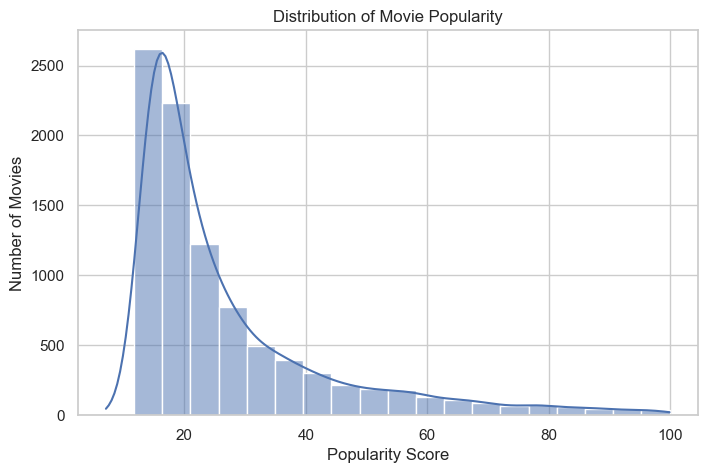

In [19]:
# Remove very large outliers
df_filtered = df[df['Popularity'] < 100]

# Plot
plt.figure(figsize=(8,5))

sns.histplot(df_filtered['Popularity'], bins=20, kde=True)

plt.title("Distribution of Movie Popularity")
plt.xlabel("Popularity Score")
plt.ylabel("Number of Movies")

plt.show()

- This chart helps decide to invest in quality movies not in quantity.
- Most movies have low popularity, only a few are very famous.
- business should focus on making less movies but high‑quality movies so that it can grow more.


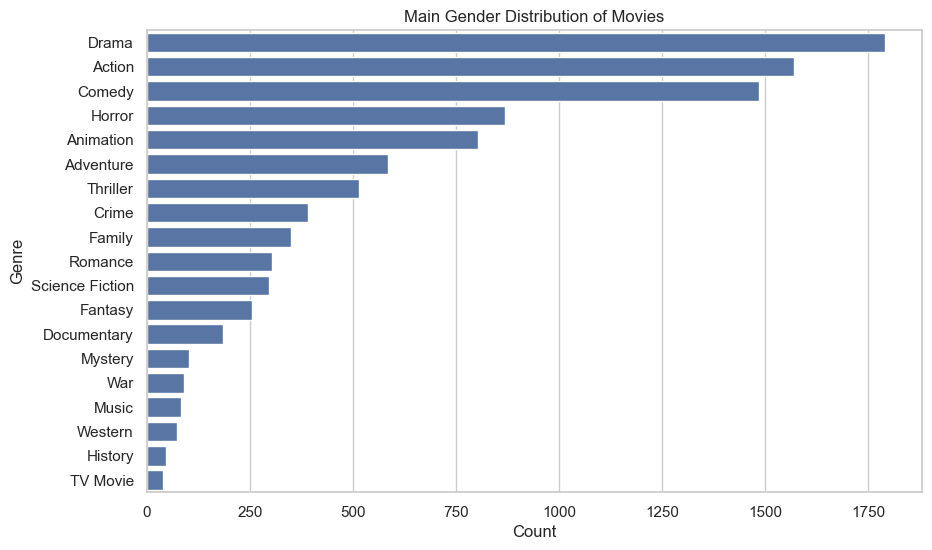

In [20]:
# Take only the first genre listed
df['Main_Genre'] = df['Genre'].str.split(',').str[0]

plt.figure(figsize=(10,6))
sns.countplot(y='Main_Genre', data=df, order=df['Main_Genre'].value_counts().index)

plt.title("Main Gender Distribution of Movies")
plt.xlabel("Count")
plt.ylabel("Genre")
plt.show()


- This chart helps to decide which genres are most popular
- Drama, Action, and Comedy have the most movies which are very highly rated in this genre.
- History, Western, and TV Movies are very low interacted movies.


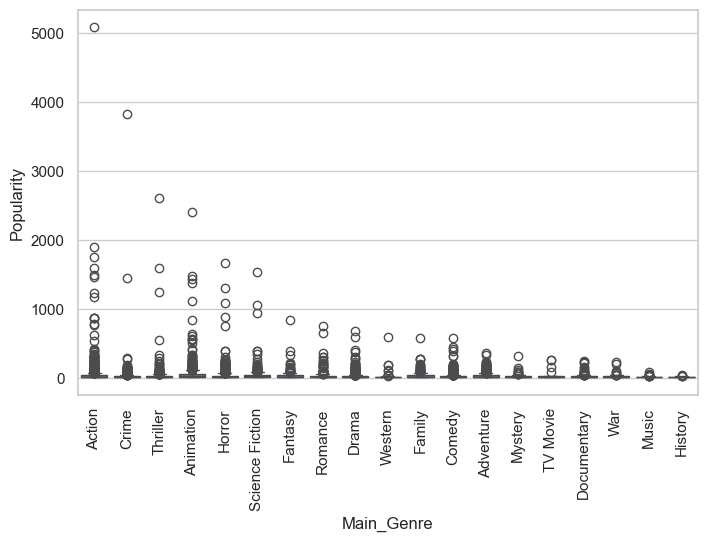

In [21]:

plt.figure(figsize=(8,5))

sns.boxplot(
    x='Main_Genre',
    y='Popularity',
    data=df
)

plt.xticks(rotation=90)
plt.show()

- This chart tells you which genres make money
- Action and Animation movies are super popular
- History and Music movies are less popular
